In [3]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
plt.rcParams.update({"font.size": 12, "figure.figsize": (6, 4)})
np.random.seed(2807)
print("emcee", emcee.__version__, "| numpy", np.__version__)


emcee 3.1.6 | numpy 1.26.4


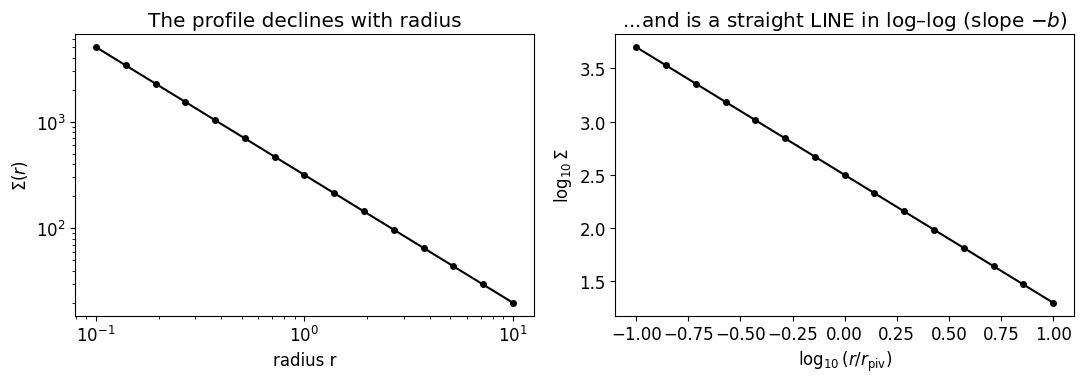

In [4]:
radii = np.logspace(-1, 1, 15)            # 15 radial bins, r = 0.1 .. 10 (e.g. arcmin or Mpc)
r_pivot = 1.0
log_r = np.log10(radii / r_pivot)         # the line's x-axis

def profile_model(theta):
    # log10 Sigma(r) = a - b log10(r/r_piv).  theta = (amplitude a, slope b).
    a, b = theta
    return a - b * log_r

a_true, b_true = 2.5, 1.2                  # one example cluster
log_sigma_true = profile_model((a_true, b_true))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(radii, 10**log_sigma_true, "k-o", ms=4)
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("radius r"); ax[0].set_ylabel(r"$\Sigma(r)$")
ax[0].set_title("The profile declines with radius")
ax[1].plot(log_r, log_sigma_true, "k-o", ms=4)
ax[1].set_xlabel(r"$\log_{10}(r/r_{\rm piv})$"); ax[1].set_ylabel(r"$\log_{10}\Sigma$")
ax[1].set_title("...and is a straight LINE in log–log (slope $-b$)")
plt.tight_layout(); plt.show()